In [8]:
import os

label_dir = "../data/Train/labels"
files = os.listdir(label_dir)[:3]  # check first 3

for f in files:
    print(f"--- {f} ---")
    with open(f"{label_dir}/{f}") as lf:
        print(lf.read())

--- 010001_jpg.rf.Gqxr32oiyiOqvObkYcc2.txt ---
2 0.3984375 0.4775390625 0.0671875 0.234375
2 0.24921875 0.52978515625 0.0609375 0.2294921875
2 0.90703125 0.11376953125 0.05625 0.1865234375
2 0.304296875 0.4990234375 0.06171875 0.224609375
2 0.6 0.640625 0.0671875 0.244140625
2 0.57109375 0.455078125 0.05 0.224609375
--- 010001_jpg.rf.Xwf47TCFAXQcCpOLu020.txt ---
2 0.9078125 0.1240234375 0.0578125 0.21484375
2 0.398828125 0.4775390625 0.06953125 0.240234375
2 0.594140625 0.63330078125 0.07890625 0.2607421875
2 0.57109375 0.45654296875 0.05625 0.2294921875
2 0.251953125 0.5302734375 0.06484375 0.228515625
2 0.301171875 0.50146484375 0.06484375 0.2373046875
--- 010002_jpg.rf.t8WHCGhDnVXNucG42ErL.txt ---
2 0.3578125 0.40576171875 0.090625 0.2470703125
2 0.8046875 0.12744140625 0.065625 0.2275390625
2 0.27578125 0.54736328125 0.103125 0.2705078125
2 0.3015625 0.4677734375 0.0734375 0.236328125


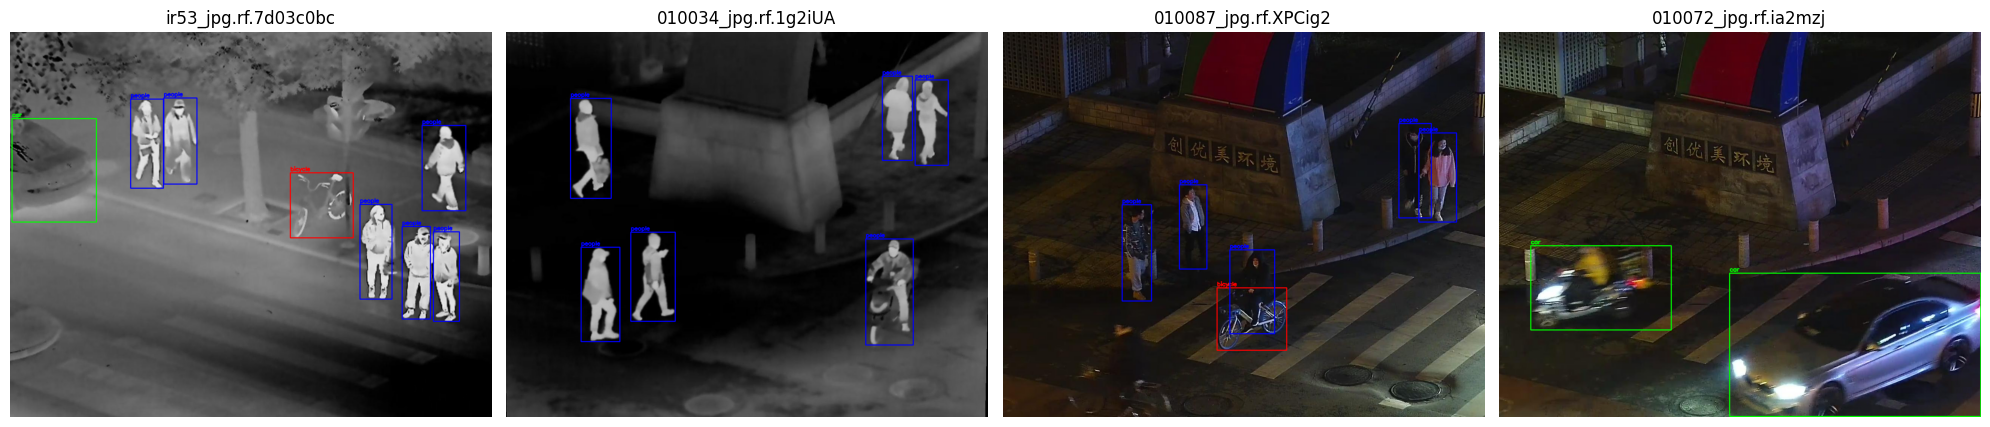

In [15]:
import cv2
import matplotlib.pyplot as plt
import os, random

def plot_sample(img_dir, label_dir, class_names, n=4):
    imgs = os.listdir(img_dir)
    samples = random.sample(imgs, n)
    
    fig, axes = plt.subplots(1, n, figsize=(20, 5))
    colors = [(255,0,0), (0,255,0), (0,0,255)]
    
    for ax, img_name in zip(axes, samples):
        img_path = f"{img_dir}/{img_name}"
        lbl_path = f"{label_dir}/{img_name.replace('.jpg','.txt').replace('.png','.txt')}"
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f.readlines():
                    cls, cx, cy, bw, bh = map(float, line.strip().split())
                    cls = int(cls)
                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w)
                    y2 = int((cy + bh/2) * h)
                    cv2.rectangle(img, (x1,y1), (x2,y2), colors[cls], 2)
                    cv2.putText(img, class_names[cls], (x1, y1-5),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors[cls], 2)
        
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(img_name[:20])
    
    plt.tight_layout()
    plt.savefig("../sample_visualization.png")
    plt.show()

plot_sample(
    "../data/Train/images",
    "../data/Train/labels",
    ['bicycle', 'car', 'people']
)